## ROC Curve

La ROC curve, Receiver Operating Characteristic, è una curva che descrive le prestazioni di un classificatore binario al variare della soglia decisionale.

Molti modelli non producono solo una classe predetta, ma anche uno score o una probabilità.

Per esempio, un modello può dire:

```text
probabilità classe positiva = 0.80
```

Normalmente potremmo usare una soglia pari a:

```text
0.5
```

Se la probabilità è maggiore o uguale a 0.5, prediciamo la classe positiva.

Se è minore di 0.5, prediciamo la classe negativa.

La ROC curve mostra cosa succede cambiando questa soglia.

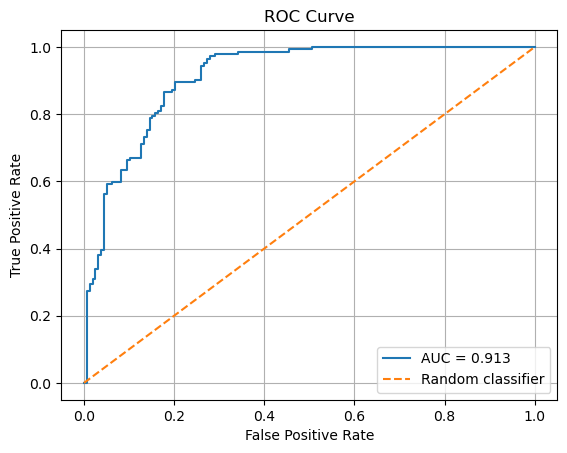

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Dataset sintetico
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Modello (probabilistico)
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

# 5. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Per un classificatore perfetto esiste una soglia per cui ha pochi falsi positivi (FPR vicino a 0) e tanti veri positivi (TRP vicino a 1). Quindi più una curva occupa l'ancolo in alto a sinistra, più il classificatore è valido.

Se la curva è la diagonale, allora per ogni soglia, se questa garantisce un basso grado di falsi positivi allora è basso anche il grado di veri positivi.

## AUC

L'AUC, Area Under the Curve, misura l'area sotto la curva ROC.

Un classificatore perfetto ha:

$$
AUC = 1
$$

Un classificatore casuale tende ad avere:

$$
AUC = 0.5
$$

Più l'AUC è alta, migliore è la capacità del modello di assegnare score più alti agli esempi positivi rispetto agli esempi negativi.
Maggiore è l'area sotto la curva (**AUC**), migliore è il classificatore. 
Quindi:

```text
AUC vicino a 1:
ottimo classificatore

AUC vicino a 0.5:
classificatore simile al caso casuale
```

La diagonale nel grafico rappresenta il comportamento di un classificatore casuale.

# Esercitazione: classificazione di Dataset Sbilanciati con SVM

Si vuole affrontare il problema della classificazione di dataset sbilanciati, costituiti da due classi:

- classe `0` (maggioritaria),
- classe `1` (minoritaria).

Si consideri un dataset sintetico con forte sbilanciamento (ad esempio 95% dei campioni appartenenti alla classe `0` e 5% alla classe `1`).


Nei dataset sbilanciati, l'accuracy può essere fuorviante.

Infatti, un modello che predice sempre la classe maggioritaria potrebbe ottenere accuracy molto alta senza imparare davvero a riconoscere la classe minoritaria.

Esempio:

```text
950 negativi
50 positivi

modello predice sempre negativo
accuracy = 950 / 1000 = 95%
```

L'accuracy sembra alta, ma il modello non riconosce nessun positivo.

## Perché precision, recall e F1 sono importanti nei dati sbilanciati

Nei dataset sbilanciati non basta guardare l'accuracy.

Dobbiamo capire come il modello si comporta sulla classe minoritaria.

Per questo sono importanti:

- matrice di confusione;
- precision;
- recall;
- F1 score;
- ROC curve;
- AUC.

Se la classe positiva è minoritaria, la recall ci dice quanti positivi reali vengono trovati.

La precision ci dice quanto sono affidabili le predizioni positive.

L'F1 score combina precision e recall in una sola metrica.

Queste metriche aiutano a evitare di scegliere un modello che sembra buono solo perché predice sempre la classe maggioritaria.


---

## 1. Bilanciamento dei dati per training e validazione

1. Generare un dataset sintetico di classificazione binaria.

2. Suddividere il dataset in:
   - training set,
   - test set.

3. **A partire dal training set, estrarre inizialmente un sottoinsieme bilanciato**, selezionando casualmente lo stesso numero di campioni per ciascuna classe, pari al numero di campioni della classe minoritaria.

4. Applicare una validazione incrociata stratificata a `K` fold sul training set bilanciato ottenuto al punto precedente.

5. Al termine della cross-validation, addestrare il modello finale su un training set bilanciato (ottenuto come al punto 3) e valutarlo su un test set non bilanciato, mantenendo la distribuzione originale delle classi, al fine di ottenere una stima realistica delle prestazioni del modello in condizioni di sbilanciamento.

6. Valutare il modello con una metrica appropriata. 



----

## 2. Modifica dell'implementazione della SVM


Si consideri la formulazione soft-margin della SVM:

$$
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{N}\xi_i
$$

Modificare l'implementazione sostituendo il parametro globale `C` con un parametro specifico per ciascun campione:

$$
C_i = C \cdot v_{i}
$$

dove:

- $v_{i}$ è il peso associato alla classe del campione $i$,

I pesi di classe sono definiti come inversamente proporzionali alla frequenza delle classi nel training set:

$$
v_c = \frac{n}{2n_c}
$$

dove:

- $n$ è il numero totale di campioni del training set,
- $n_c$ è il numero di campioni appartenenti alla classe $c$.

In questo modo:

- la classe maggioritaria riceve un peso minore;
- la classe minoritaria riceve un peso maggiore;
- gli errori sui campioni della classe minoritaria vengono penalizzati maggiormente.


---

## 3. Valutazione sperimentale

Implementare la nuova versione della SVM e ripetere la stessa procedura di cross-validation e test descritta al punto 1, mantenendo:

- training set sbilanciato;
- validation set sbilanciato;
- test set sbilanciato.

Confrontare i risultati ottenuti con quelli della strategia basata sul bilanciamento esplicito dei dati.




---

## 4. Discussione finale

Confrontare le due strategie:

1. bilanciamento esplicito di training e validation set;
2. modifica della funzione obiettivo tramite pesi `C_i`.
3. Discutere vantaggi e svantaggi di ciascun approccio e indicare in quali situazioni pratiche uno dei due metodi possa essere preferibile all'altro.